In [9]:
from retinotopy import *

Running on GPU :  NVIDIA GeForce RTX 4060 Laptop GPU #GPU= 1
------------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host Newton with device cuda, pytorch==2.6.0.dev20241222+cu124
------------------------------------------------------------------------------------------------------
Welcome on Windows-11-10.0.26100-SP0
Random seed 1998 has been set.


In [10]:
data_set_types = ['raw', 'bbox', 'full']

In [11]:
def get_map_save(args, map, i_image):
    #mean_map = torch.stack(map).mean(dim=0)  
    map /= i_image
    #mean_map = map.mean(dim=0)  
    map = np.array(map.cpu())
    #return mean_map.reshape(args.resolution[0]*args.resolution[1])
    return map

In [13]:
args = Params()
im_zero = ((args.resolution[0]*args.resolution[1])//2)
args.do_translate = True
args.do_resize = True
for data_set_type in data_set_types: 
    print(50*'=')
    data_set_type_test = data_set_type if data_set_type != 'raw' else 'full'
    print(f'{data_set_type=}')    
    #args.do_rot_train = True
    args.do_mask = False
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type_test}' # Directory containing images
    args.folders = ['val'] # type of images to use
    print(50*'-')


    for model_name in  ['resnet101'] : #, 
        print(f'{model_name=}')

        for do_polar in [True, False]:
            do_polar = do_polar if data_set_type != 'raw' else False
            args.do_polar = do_polar
            print(f'{args.do_polar=}')
            print(50*'.')
            attack_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_attack_translate_acc.parquet'
            df_filename_acc = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_translate_accuracy_acc.parquet'
            if os.path.isfile(df_filename_acc):
                df_translate = pd.read_parquet(df_filename_acc)
            else:
                print(args)
                df_mean, df_attack = None, None
                print(f'Computing {df_filename_acc}')

                image_dataset = image_datasets_transforms(args)

                #model_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt'
                model_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt' if data_set_type != 'raw' else None

                #if os.path.isfile(model_filename):
                print(f"Loading pre-trained resnet {model_filename}")
                model = charge_model(model_name=model_name, model_path=model_filename, do_circular=args.do_polar).to(device).eval()
            
                pprint(f'Testing : {model_name}')

                torch.cuda.amp.GradScaler(enabled=True)
                model = model.eval()
#                pred_translate = []
                pred_translate = torch.zeros(args.resolution[0]*args.resolution[1])
                with torch.no_grad():
                    for i_image, (data, label) in tqdm(enumerate(image_dataset)) : 
                        label_batch = (torch.ones([len(data)])*label).data
                        data = data.to(device)
                
                        outputs = model(data)
                
                        outputs = torch.softmax(outputs, dim=1)
                
                        prior_outputs = outputs[:,label]
                        
                        argmax = torch.argmax(prior_outputs) 
                        argmin = torch.argmin(prior_outputs) 
                
                        _, preds = torch.max(outputs.data.cpu(), dim=1)

                        avg_acc = ((preds == torch.ones([len(data)])*label)*1.).cpu()

                        pred_translate += avg_acc.cpu()

                        
                        df_attack_ = pd.DataFrame({'likelihood_0':[prior_outputs[im_zero].item()], '0_pred':torch.argmax(outputs[im_zero]).item(), 
                                            'likelihood_max':prior_outputs[argmax].item(), 'max_pos':argmax.item(), 'max_pred':torch.argmax(outputs[argmax]).item(), 
                                            'likelihood_min':prior_outputs[argmin].item(), 'min_pos':argmin.item(), 'min_pred':torch.argmax(outputs[argmin]).item(),
                                            'i_image':i_image, 'filename':image_dataset.imgs[i_image][0], 'label':label})
                        
                        df_attack = store_pandas(df_attack, df_attack_)
                        if torch.cuda.is_available(): torch.cuda.empty_cache()   
                    
                    
                    df_mean_ = pd.DataFrame({'mean_accuracy':[get_map_save(args, pred_translate, (i_image+1))]})
                    df_mean = store_pandas(df_mean, df_mean_)
                    model.cpu()
                    df_mean.to_parquet(df_filename_acc)
                    df_attack.to_parquet(attack_filename)

data_set_type='raw'
--------------------------------------------------
model_name='resnet101'
args.do_polar=False
..................................................
args.do_polar=False
..................................................
data_set_type='bbox'
--------------------------------------------------
model_name='resnet101'
args.do_polar=True
..................................................
args.do_polar=False
..................................................
data_set_type='full'
--------------------------------------------------
model_name='resnet101'
args.do_polar=True
..................................................
args.do_polar=False
..................................................


In [15]:
#Rotation attack read out
acc_plot = {}
for model_name in  ['resnet18', 'resnet50', 'resnet101']:
    print(50*'=')
    print(f'{model_name=}')
    for data_set_type, ls in zip(data_set_types, data_set_linestyles):
        print(f'{data_set_type=}')
        print(50*'-')

        for do_polar, color in zip([True, False], ['b', 'r']):

            df_filename_acc = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_results_attack_translate_acc.parquet'
            

            if os.path.isfile(df_filename_acc):

                df_zoom = pd.read_parquet(df_filename_acc)
                print(do_polar)
                min = accuracy_score(df_zoom['min_pred'], df_zoom["label"])
                print(min, 'min_pred')
                zero = accuracy_score(df_zoom['0_pred'], df_zoom["label"])
                print(zero, 'zero')
                max_acc = accuracy_score(df_zoom['max_pred'], df_zoom["label"])
                print(max_acc, 'max_pred')
                print(zero-min, 'delta1', max_acc-zero, 'delta2')

                acc_plot[get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_min'] = min

                acc_plot[get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '_zero'] = zero


model_name='resnet18'
data_set_type='raw'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='full'
--------------------------------------------------
model_name='resnet50'
data_set_type='raw'
--------------------------------------------------
data_set_type='bbox'
--------------------------------------------------
data_set_type='full'
--------------------------------------------------
model_name='resnet101'
data_set_type='raw'
--------------------------------------------------
False
0.55902 min_pred
0.79956 zero
0.90016 max_pred
0.2405400000000001 delta1 0.10059999999999991 delta2
data_set_type='bbox'
--------------------------------------------------
True
0.10124 min_pred
0.77444 zero
0.944 max_pred
0.6732 delta1 0.16955999999999993 delta2
False
0.57596 min_pred
0.83012 zero
0.92304 max_pred
0.25415999999999994 delta1 0.09292 delta2
data_set_type='full'
-----------------------------------------------

In [16]:
def get_mean_map(model_data_set_type, model_name):

    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, True) + f'_results_translate_accuracy_acc.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
    ret_map = np.array(df['mean_accuracy'][0].reshape(args.resolution[0], args.resolution[1]))
    
    
    df_filename = get_filename(data_cache, datetag, model_data_set_type, model_name, False) + f'_results_translate_accuracy_acc.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
    cart_map = np.array(df['mean_accuracy'][0].reshape(args.resolution[0], args.resolution[1]))
    
    
    df_filename = get_filename(data_cache, datetag, 'raw', model_name, False) + f'_results_translate_accuracy_acc.parquet'
    print(f'{df_filename=}')
    with open(df_filename, 'r') as csv_file:
        df = pd.read_parquet(df_filename)
    raw_map = np.array(df['mean_accuracy'][0].reshape(args.resolution[0], args.resolution[1]))
    
    return raw_map, cart_map, ret_map

raw_map, cart_map, ret_map = get_mean_map('full', 'resnet101')

df_filename='cached_data/2024-05-24_full_resnet101_retino_results_translate_accuracy_acc.parquet'
df_filename='cached_data/2024-05-24_full_resnet101_cartesian_results_translate_accuracy_acc.parquet'
df_filename='cached_data/2024-05-24_raw_resnet101_cartesian_results_translate_accuracy_acc.parquet'


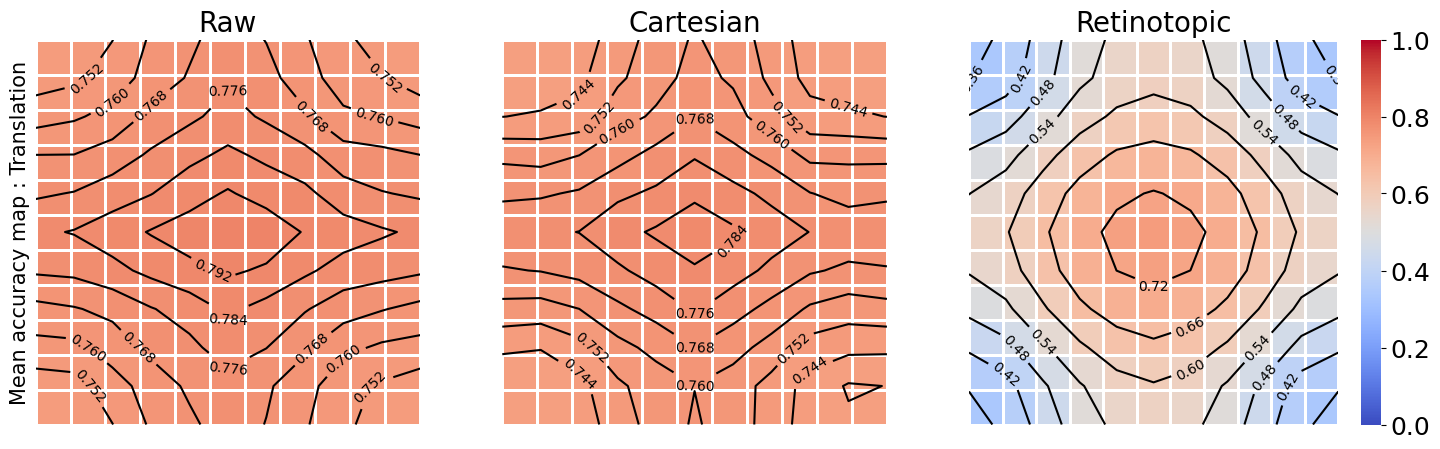

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5), width_ratios=[1, 1, 1.2])
i = 0
all_titles = ['Raw', 'Cartesian', 'Retinotopic']
for i_model, result_map in enumerate([raw_map, cart_map, ret_map]):

    ax = axs[i_model]
    title_mod = all_titles[i_model]
    cbar = True if i_model == 2 else False
    X, Y = np.meshgrid(np.linspace(0, args.resolution[0], args.resolution[0]), np.linspace(0, args.resolution[1], args.resolution[1]))
    Z = result_map
    levels = np.linspace(Z.min(), Z.max(), max(args.resolution))
    
    sns.heatmap(result_map, linewidth = 1 , annot = False, cmap='coolwarm', vmin=0, vmax=1, fmt='.2g', cbar = cbar, ax=ax,annot_kws={"fontsize":9})
    CS = ax.contour(X, Y, Z, colors='black' )
    ax.clabel(CS, inline=True, fontsize=10)
    ax.set_title(f'{title_mod}', size = 20)
    ax.set_xticks([])
    ax.set_yticks([])
axs[0].set_ylabel('Mean accuracy map : Translation', size = 15)
    #ax.imshow(result_map)

if False:
    to_save(fig, 'fig-mean_map_Imagenet_paper')

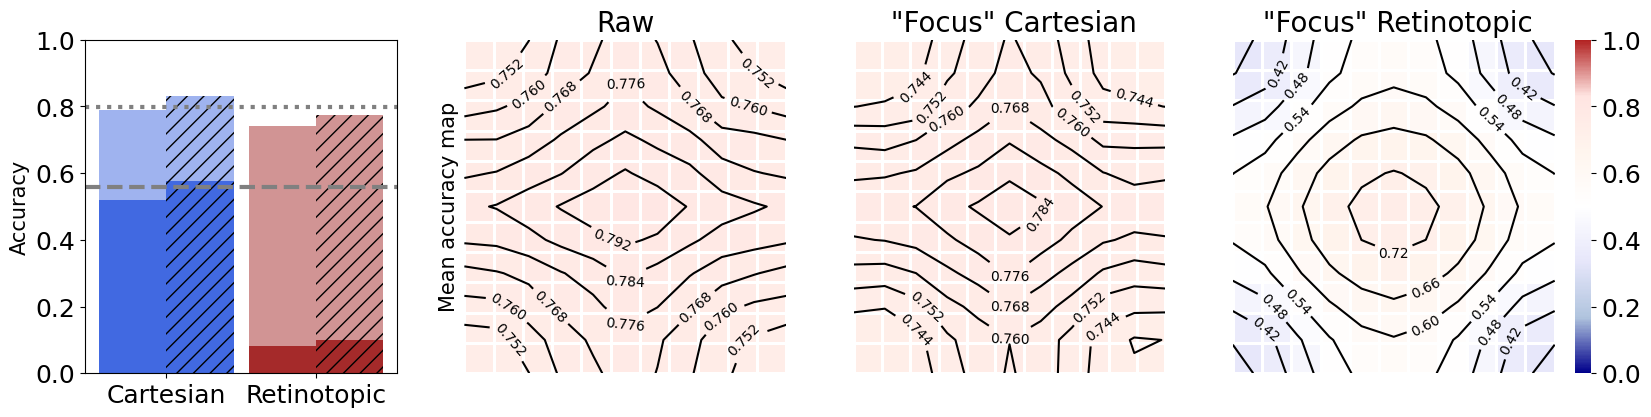

In [22]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
fig, axs = plt.subplots(1, 4, sharex=False, sharey=False, figsize=(fig_width, fig_width/4.61803), width_ratios=[1.55, 1.6, 1.55, 2])
titles = ["(A) Zoom out attack", "(B) Zoom sensitivity"]
model_name = 'resnet101'
#colors_cart = ['lightsteelblue', 'brown']
colors = ['royalblue', 'brown']
acc_full_ret_min = acc_plot[get_filename(data_cache, datetag, 'full', model_name, True) + '_min']

acc_full_ret = acc_plot[get_filename(data_cache, datetag, 'full', model_name, True) + '_zero']

acc_full_lin_min = acc_plot[get_filename(data_cache, datetag, 'full', model_name, False) + '_min']

acc_full_lin = acc_plot[get_filename(data_cache, datetag, 'full', model_name, False) + '_zero']

acc_bbox_ret_min = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, True) + '_min']

acc_bbox_ret = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, True) + '_zero']

acc_bbox_lin_min = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, False) + '_min']

acc_bbox_lin = acc_plot[get_filename(data_cache, datetag, 'bbox', model_name, False) + '_zero']

acc_notrain = acc_plot[get_filename(data_cache, datetag, 'raw', model_name, False) + '_zero']

acc_notrain_min = acc_plot[get_filename(data_cache, datetag, 'raw', model_name, False) + '_min']


type_mod = ("Cartesian", "Retinotopic")
data_means = {
    'full image': (acc_full_lin, acc_full_ret),
    'bounding box': (acc_bbox_lin, acc_bbox_ret ),

}

x = np.arange(len(type_mod))  # the label locations
width = 0.45  # the width of the bars
multiplier = 0
hatchs = [None, "//"]

for i, (attribute, measurement) in enumerate(data_means.items()):
    offset = width * multiplier
    rects = axs[0].bar(x + offset, measurement, width, label=attribute, alpha =.5, color = colors, hatch=hatchs[i])
    #axs[0].bar_label(rects, padding=2)
    multiplier += 1

data_means = {
    'full image': (acc_full_lin_min, acc_full_ret_min),
    'bounding box': (acc_bbox_lin_min, acc_bbox_ret_min )
}
multiplier = 0

for i, (attribute, measurement) in enumerate(data_means.items()):
    offset = width * multiplier
    rects = axs[0].bar(x + offset, measurement, width, color = colors, hatch=hatchs[i])
    #axs[0].bar_label(rects, padding=2)
    multiplier += 1

axs[0].axhline(y=0.799, c='gray', ls='dotted', lw=3, label='before attack')
axs[0].axhline(y=0.559, c='gray', ls='--', lw=3, label='after attack')

axs[0].set_xticks(x + width/2, type_mod)
axs[0].set_ylabel('Accuracy', font=font, fontsize=15)
axs[0].legend(loc='upper left', ncols=2, fontsize=15)
axs[0].set_ylim(0, 1)
legend = axs[0].legend()
legend.remove()

i = 0
all_titles = ['Raw', 'Cartesian', 'Retinotopic']
for i_model, result_map in enumerate([raw_map, cart_map, ret_map]):

    ax = axs[i_model+1]
    title_mod = all_titles[i_model] if 'aw' in all_titles[i_model] else """ "Focus" """ + all_titles[i_model]
    cbar = True if i_model == 2 else False
    X, Y = np.meshgrid(np.linspace(0, args.resolution[0], args.resolution[0]), np.linspace(0, args.resolution[1], args.resolution[1]))
    Z = result_map
    levels = np.linspace(Z.min(), Z.max(), max(args.resolution))
    
    sns.heatmap(result_map, linewidth = 1 , annot = False, cmap=cmap, vmin=0, vmax=1, fmt='.2g', cbar = cbar, ax=ax,annot_kws={"fontsize":9})
    CS = ax.contour(X, Y, Z, colors='black' )
    ax.clabel(CS, inline=True, fontsize=10)
    ax.set_title(f'{title_mod}', size = 20)
    ax.set_xticks([])
    ax.set_yticks([])
axs[1].set_ylabel('Mean accuracy map', size = 15)
    #ax.imshow(result_map)

if False:
    to_save(fig, 'fig-mean_accuracy_translation_paper')

In [ ]:
args = Params()

args.root  = f'{DATAROOT}/Imagenet_full' # Directory containing images
args.folders = ['val'] # type of images to use
args.do_polar = False
args.do_mask = False
image_dataset = image_datasets_transforms(args)

In [ ]:
imshow(apply_grid(image_dataset[1][0], get_grid(args).unsqueeze(0)))

In [ ]:
imshow(image_dataset[1][0])

In [ ]:
def generate_translate_roll_grids(args):
    """
    Generate grids for `nnf.grid_sample` where each fixation point rolls the image
    without losing information, mimicking `np.roll` behavior.
    
    Args:
        image_shape (tuple): Shape of the original image as (C, H, W).
        n_fixation_points (int): Number of fixation points along each axis.

    Returns:
        torch.Tensor: A tensor of shape [n_fixation_points^2, C, W, H],
                      with each fixation point shifted and wrapped around.
    """
    
    if args.do_polar:
        # Generate base log-polar grid
        start = get_start(1)
        rs_ = torch.logspace(start, args.rs_max, args.image_size, base=2)  # Radial distances (log scale)
        ts_ = torch.linspace(0, torch.pi * 2, args.image_size + 1)[:-1]  # Angular positions (full circle)

        grid_x = torch.outer(rs_, torch.cos(ts_))
        grid_y = torch.outer(rs_, torch.sin(ts_))
        base_grid = torch.stack((grid_x, grid_y), dim=2)  # (H_scaled, W_scaled, 2)
        # Normalize the log-polar grid to range [-1, 1]
        base_grid[..., 0] = 2 * (base_grid[..., 0] - base_grid[..., 0].min()) / (base_grid[..., 0].max() - base_grid[..., 0].min()) - 1
        base_grid[..., 1] = 2 * (base_grid[..., 1] - base_grid[..., 1].min()) / (base_grid[..., 1].max() - base_grid[..., 1].min()) - 1
    else:
        grid_y = torch.linspace(-1, 1, args.image_size)
        grid_x = torch.linspace(-1, 1, args.image_size)
        base_grid = torch.stack(torch.meshgrid(grid_y, grid_x, indexing='ij'), dim=-1)  # (H, W, 2)

        
        base_grid[..., 0] = -base_grid[..., 0]
        base_grid = base_grid[..., [1, 0]]  # Swap x and y axes
        base_grid[..., 1] = -base_grid[..., 1]  # Invert the new y-axis (originally x-axis)

    # Create linear fixation points
    fixation_points_x = torch.linspace(1, -1, args.resolution[0])
    fixation_points_y = torch.linspace(1, -1, args.resolution[1])
    fixation_grid = torch.stack(torch.meshgrid(fixation_points_x, fixation_points_y, indexing='ij'), dim=-1)

    roll_grid = []
    for point in fixation_grid.view(-1, 2):
        shifted_grid = base_grid.clone()
        shifted_grid[..., 0] -= point[1]  # Shift x-axis (horizontal)
        shifted_grid[..., 1] -= point[0]  # Shift y-axis (vertical)

        # Wrap around grid values to simulate rolling
        shifted_grid[..., 0] = torch.remainder(shifted_grid[..., 0] + 1, 2) - 1
        shifted_grid[..., 1] = torch.remainder(shifted_grid[..., 1] + 1, 2) - 1

        roll_grid.append(shifted_grid)

    # Stack into [n_fixation_points^2, H, W, 2]
    roll_grid = torch.stack(roll_grid, dim=0)

    return roll_grid

In [ ]:
args.do_polar = False
generate_translate_roll_grids(args).shape

In [ ]:
images = apply_grid(image_dataset[1][0].unsqueeze(0),generate_fixation_grids_wrap(args))

In [ ]:
imshow(images[60])

In [ ]:
imshow(image_dataset[1][0])

In [ ]:
args.do_polar = True
generate_translate_roll_grids(args).shape

In [ ]:
images = apply_grid(image_dataset[1][0],generate_fixation_polar_wrap(args))

In [ ]:
imshow(images[60])

In [ ]:
imshow(apply_grid(image_dataset[1][0], get_grid(args).unsqueeze(0)))